# Lab 22: Stacked Charts - Data Visualization
## IBM Data Analytics Capstone Project 
### Objective: Visualize composition and comparisons using stacked charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (65437, 114)


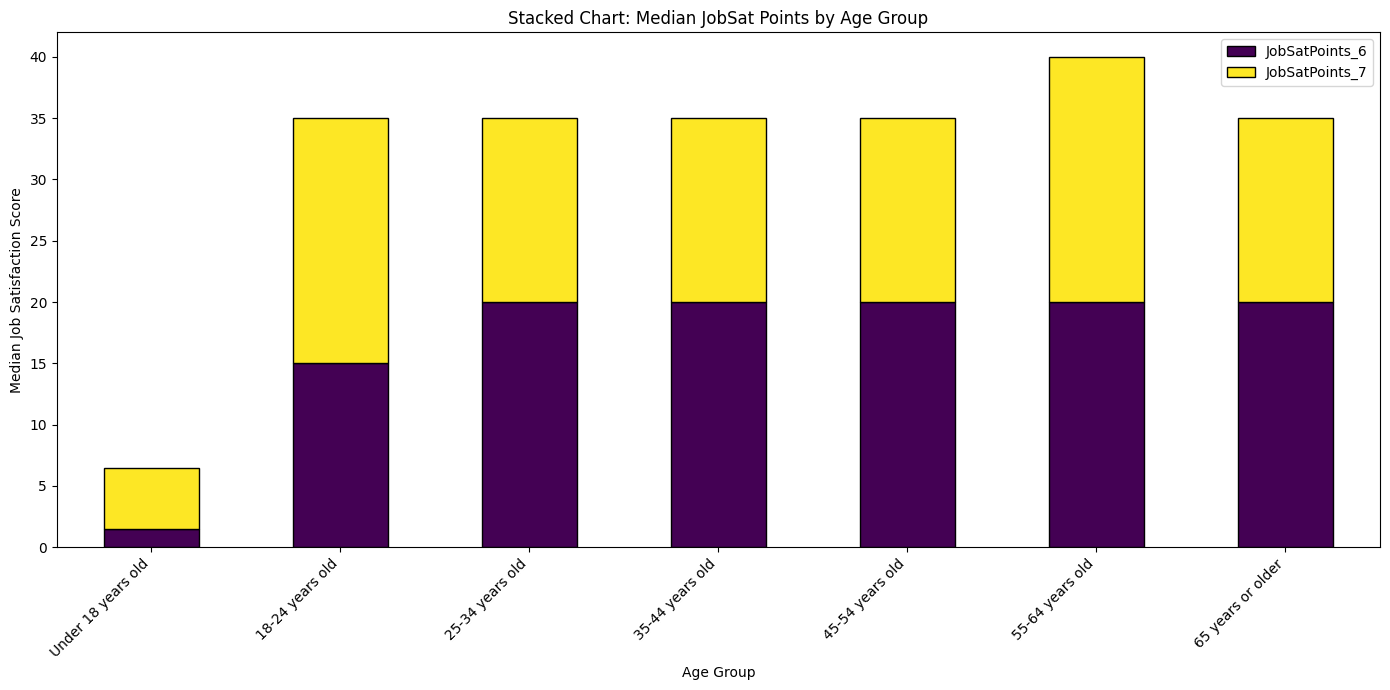

JobSat by age saved!


In [2]:
# Median JobSatPoints_6 and JobSatPoints_7 by Age
df_age_sat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().reindex(age_order).dropna()

ax = df_age_sat.plot(kind='bar', stacked=True, figsize=(14, 7), 
                     colormap='viridis', edgecolor='black')
plt.title('Stacked Chart: Median JobSat Points by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.tight_layout()
plt.savefig('stacked_jobsat_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("JobSat by age saved!")

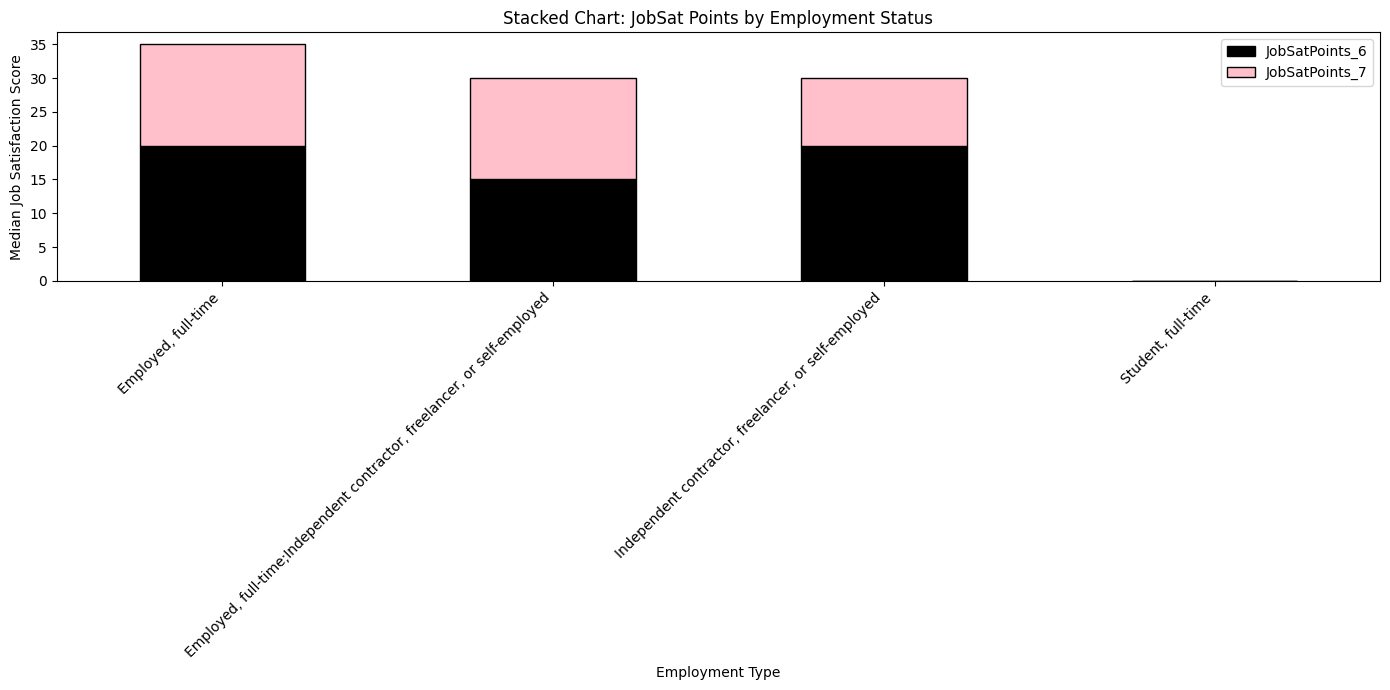

JobSat by employment saved


In [6]:
# Fixed: use explicit colors - pink and black
df_emp_sat.plot(kind='bar', stacked=True, figsize=(14, 7),
                color=['black', 'pink'], edgecolor='black')
plt.title('Stacked Chart: JobSat Points by Employment Status')
plt.xlabel('Employment Type')
plt.ylabel('Median Job Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('stacked_jobsat_employment.png', dpi=150, bbox_inches='tight')
plt.show()
print("JobSat by employment saved")

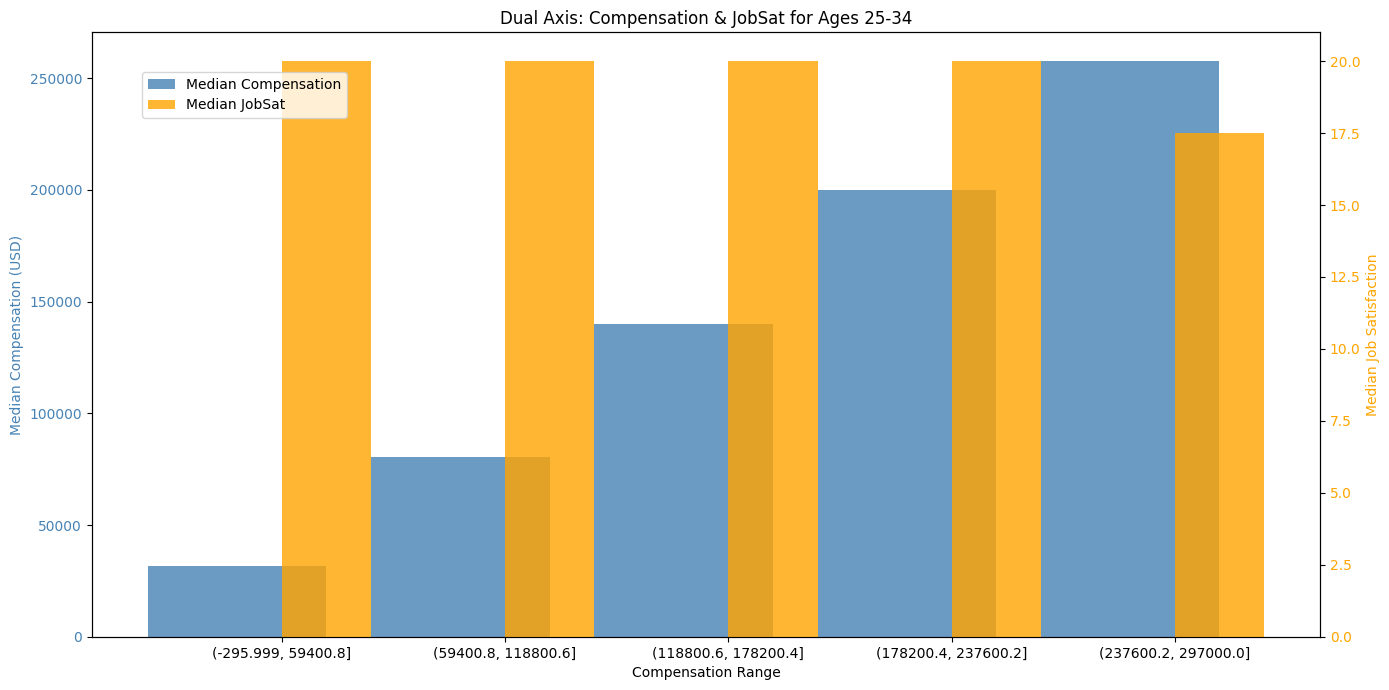

Compensation & JobSat for 25-34 saved


In [11]:
# Filter for 25-34 age group (closest to 30-35)# 
df_30_35 = df[df['Age'] == '25-34 years old'][['ConvertedCompYearly', 'JobSatPoints_6']].dropna()
df_30_35 = df_30_35[df_30_35['ConvertedCompYearly'] < 300000]

df_30_35['CompBin'] = pd.cut(df_30_35['ConvertedCompYearly'], bins=5)
stacked_data = df_30_35.groupby('CompBin', observed=True)[['ConvertedCompYearly', 'JobSatPoints_6']].median()

fig, ax1 = plt.subplots(figsize=(14, 7))
x = range(len(stacked_data))

ax1.bar(x, stacked_data['ConvertedCompYearly'], color='steelblue',
        label='Median Compensation', alpha=0.8)
ax1.set_xlabel('Compensation Range')
ax1.set_ylabel('Median Compensation (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + 0.4 for i in x], stacked_data['JobSatPoints_6'],
        color='orange', label='Median JobSat', alpha=0.8, width=0.4)
ax2.set_ylabel('Median Job Satisfaction', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Dual Axis: Compensation & JobSat for Ages 25-34')
plt.xticks([i + 0.2 for i in x], [str(b) for b in stacked_data.index], 
           rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('stacked_comp_jobsat_30_35.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation & JobSat for 25-34 saved")

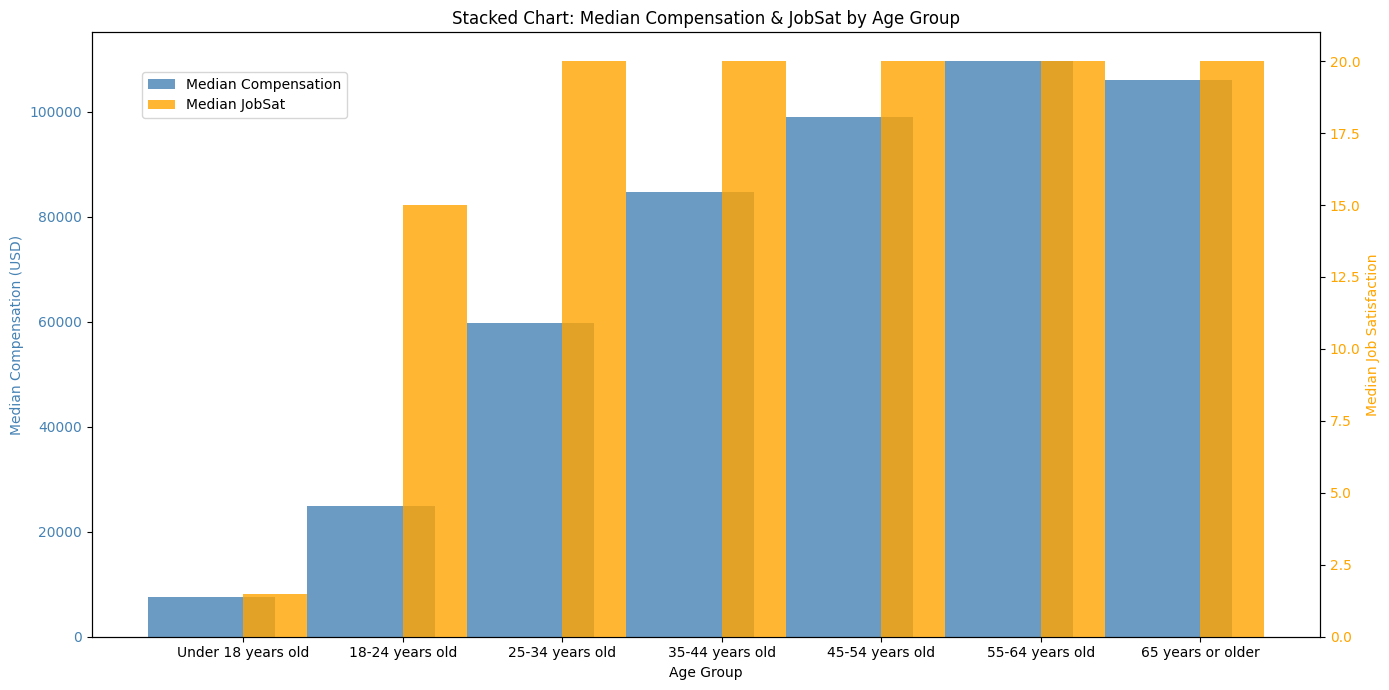

Fixed dual-axis chart saved!


In [10]:
# Fixed: dual axis to show both metrics clearly
fig, ax1 = plt.subplots(figsize=(14, 7))

x = range(len(df_age_comp))
ax1.bar(x, df_age_comp['MedianComp'], color='steelblue', 
        label='Median Compensation', alpha=0.8)
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Median Compensation (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Second axis for JobSat
ax2 = ax1.twinx()
ax2.bar([i + 0.4 for i in x], df_age_comp['MedianJobSat'], 
        color='orange', label='Median JobSat', alpha=0.8, width=0.4)
ax2.set_ylabel('Median Job Satisfaction', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Stacked Chart: Median Compensation & JobSat by Age Group')
plt.xticks([i + 0.2 for i in x], df_age_comp.index, rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('stacked_comp_jobsat_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fixed dual-axis chart saved!")

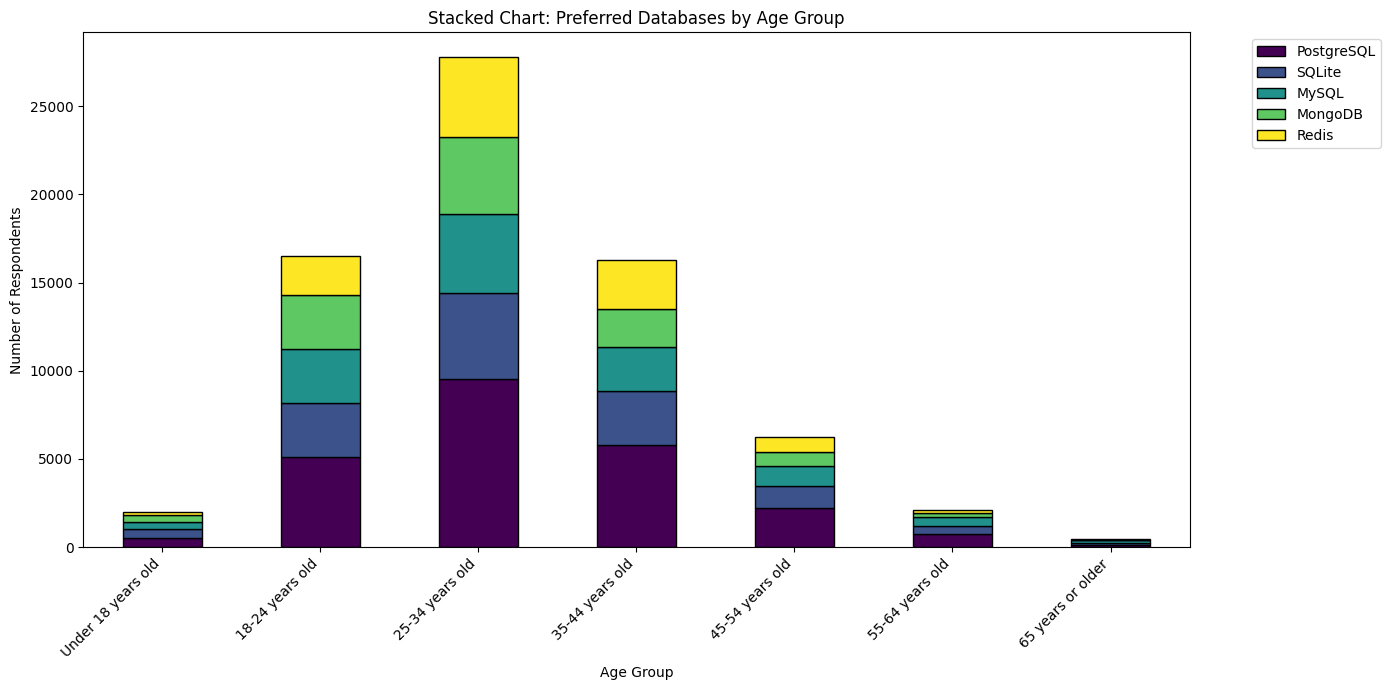

Databases by age group saved!


In [12]:
# Top 5 databases by age group
top5_db = df['DatabaseWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(5).index.tolist()

db_age_data = {}
for db in top5_db:
    db_age_data[db] = []
    for age in age_order:
        mask = (df['DatabaseWantToWorkWith'].str.contains(db, na=False)) & (df['Age'] == age)
        db_age_data[db].append(mask.sum())

df_db_age = pd.DataFrame(db_age_data, index=age_order)

ax = df_db_age.plot(kind='bar', stacked=True, figsize=(14, 7),
                    colormap='viridis', edgecolor='black')
plt.title('Stacked Chart: Preferred Databases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('stacked_db_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Databases by age group saved!")

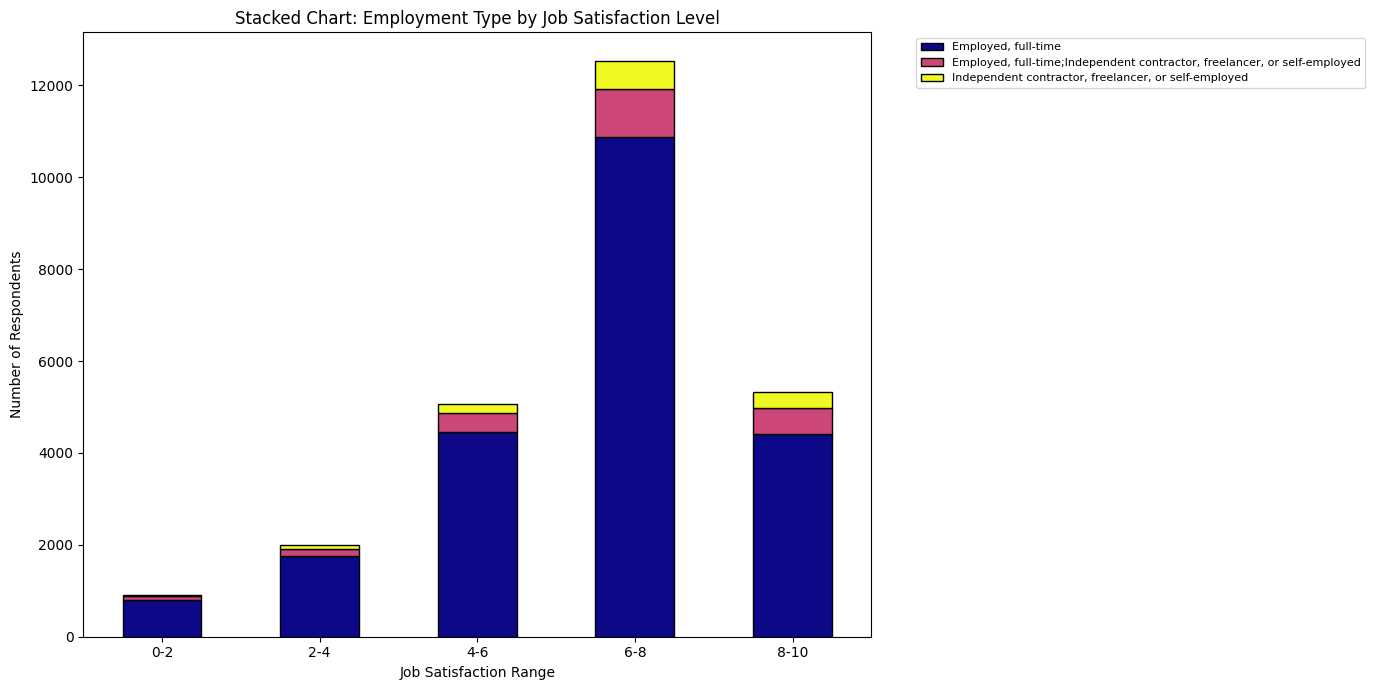

Employment by JobSat saved!


In [13]:
# Employment distribution by JobSat level
top4_emp = df['Employment'].value_counts().head(4).index.tolist()
jobsat_bins = [0, 2, 4, 6, 8, 10]
jobsat_labels = ['0-2', '2-4', '4-6', '6-8', '8-10']

df['JobSat_Bin'] = pd.cut(df['JobSat'], bins=jobsat_bins, labels=jobsat_labels)
df_emp_jobsat = df[df['Employment'].isin(top4_emp)].groupby(
    ['JobSat_Bin', 'Employment'], observed=True).size().unstack(fill_value=0)

ax = df_emp_jobsat.plot(kind='bar', stacked=True, figsize=(14, 7),
                        colormap='plasma', edgecolor='black')
plt.title('Stacked Chart: Employment Type by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Range')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('stacked_emp_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Employment by JobSat saved!")

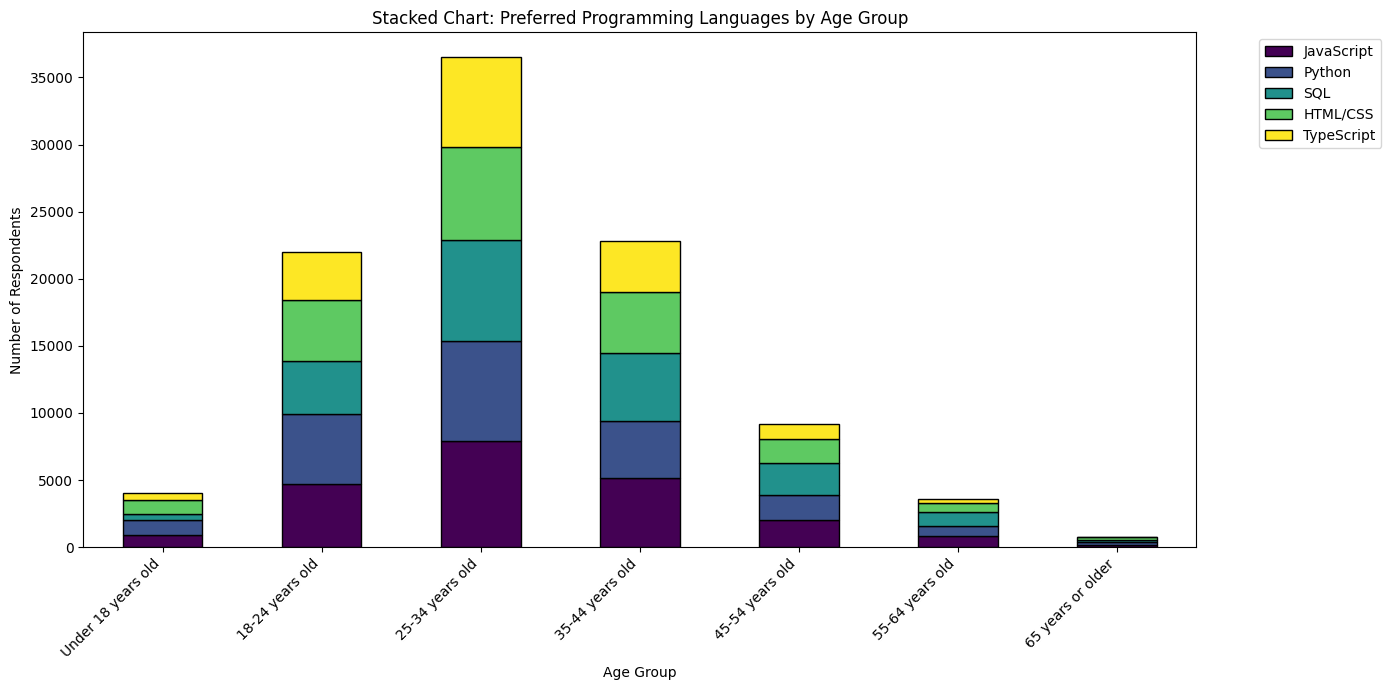

Languages by age group saved!


In [14]:
# Top 5 admired languages by age group
top5_langs = df['LanguageAdmired'].dropna().str.split(';').explode().value_counts().head(5).index.tolist()

lang_age_data = {}
for lang in top5_langs:
    lang_age_data[lang] = []
    for age in age_order:
        mask = (df['LanguageAdmired'].str.contains(lang, na=False)) & (df['Age'] == age)
        lang_age_data[lang].append(mask.sum())

df_lang_age = pd.DataFrame(lang_age_data, index=age_order)

ax = df_lang_age.plot(kind='bar', stacked=True, figsize=(14, 7),
                      colormap='viridis', edgecolor='black')
plt.title('Stacked Chart: Preferred Programming Languages by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('stacked_lang_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Languages by age group saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_10669/1428295057.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = (df['PlatformAdmired'].str.contains(platform, na=False)) & (df['Employment'] == emp)


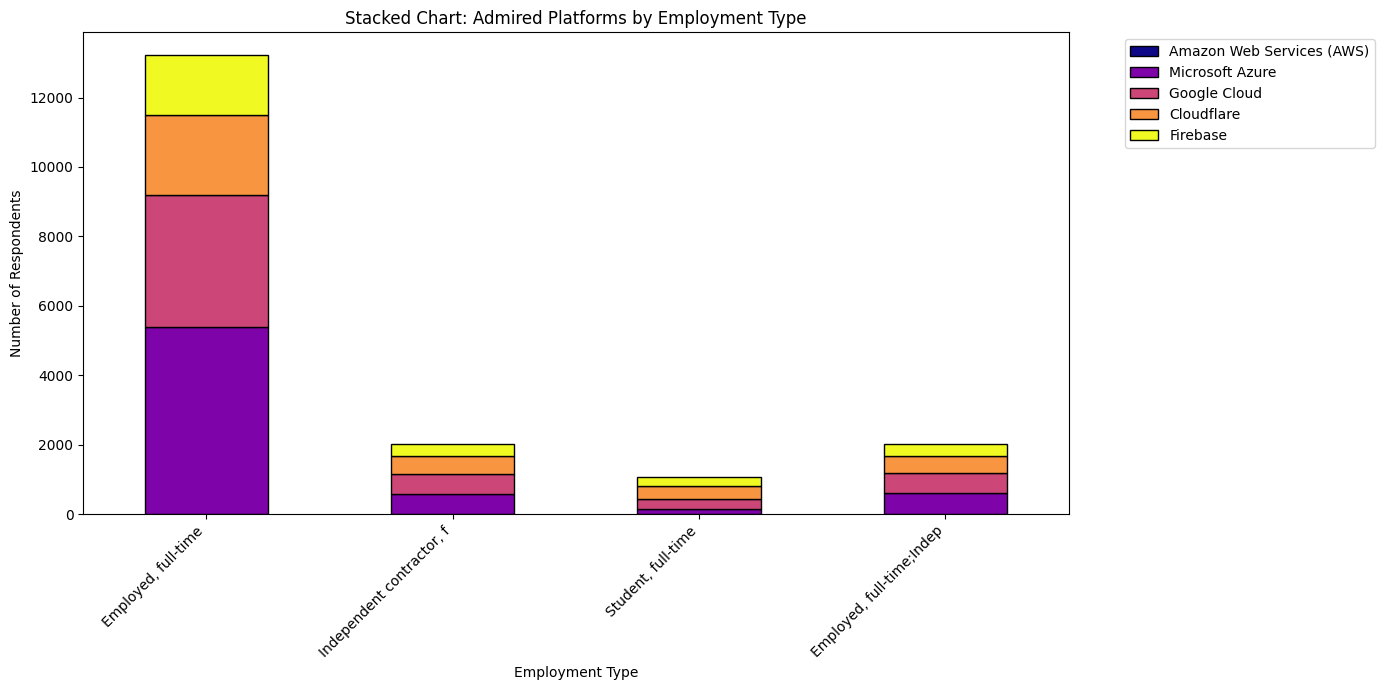

✅ Platforms by employment type saved!


In [15]:
# Top 5 admired platforms by top 4 employment types
top5_platforms = df['PlatformAdmired'].dropna().str.split(';').explode().value_counts().head(5).index.tolist()
top4_emp = df['Employment'].value_counts().head(4).index.tolist()

platform_emp_data = {}
for platform in top5_platforms:
    platform_emp_data[platform] = []
    for emp in top4_emp:
        mask = (df['PlatformAdmired'].str.contains(platform, na=False)) & (df['Employment'] == emp)
        platform_emp_data[platform].append(mask.sum())

df_platform_emp = pd.DataFrame(platform_emp_data, index=[e[:25] for e in top4_emp])

ax = df_platform_emp.plot(kind='bar', stacked=True, figsize=(14, 7),
                          colormap='plasma', edgecolor='black')
plt.title('Stacked Chart: Admired Platforms by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('stacked_platform_emp.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Platforms by employment type saved!")